In [9]:
from gunicorn.util import positionals
from matplotlib.pyplot import xlabel
from astropy.wcs import WCS
import numpy as np

import lis2.skeletons.utils as utils
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

In [50]:
bas = "../../../BIGSF_DATA/Clustering_COHRS"
path_cors = "PE_UNet_ss_mm_3_binarize_segmentation_local_threshold.fits"
data_spine_2 = fits.open(os.path.join(bas, path_cors))
path_3Ddata = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_10p50_0p00_CUBE_3T2_R2.fit"
#path_3Ddata_reprojected = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_reprojected_10p50_0p00_CUBE_3T2_R2.fits"
path_3Ddata_reprojected = "../../../BIGSF_DATA/Clustering_COHRS/COHRS_reprojected_Unet.fits"


In [58]:
data_reproject = fits.open(path_3Ddata_reprojected)
data_3D = fits.open(path_3Ddata)
wcs_3d = WCS(data_3D[0].header.copy())
wcs_3d_1 = wcs_3d.celestial
wcs_2d = WCS(data_spine_2[0].header.copy())
data_s2_wcs = WCS(data_spine_2[0].header)

In [7]:
print(data_spine_2[0].data.shape)

(1111, 3871)


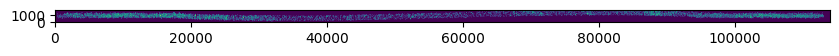

(1800, 114000)


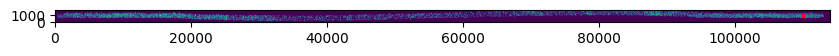

In [59]:
plt.figure(figsize=(10, 10))
plt.imshow(data_spine_2[0].data, origin='lower')
plt.show()
print(data_spine_2[0].data.shape)
wcs_2d = WCS(data_spine_2[0].header.copy())
plt.figure(figsize=(10, 10))
plt.imshow(data_spine_2[0].data, origin='lower')
corners_world = wcs_3d_1.calc_footprint()
min_ra, min_dec = corners_world.min(axis=0)
max_ra, max_dec = corners_world.max(axis=0)

# Find these corners inside 2D mask data
min_pix_x, min_pix_y = data_s2_wcs.world_to_pixel_values(min_ra, min_dec)
max_pix_x, max_pix_y = data_s2_wcs.world_to_pixel_values(max_ra, max_dec)
min_pix_x, max_pix_x = int(min_pix_x), int(max_pix_x)
min_pix_y, max_pix_y = int(min_pix_y), int(max_pix_y)
plt.plot([min_pix_x, max_pix_x ], [min_pix_y, min_pix_y], 'r')
plt.plot([min_pix_x, min_pix_x], [min_pix_y, max_pix_y], 'r')
plt.plot([max_pix_x, max_pix_x ], [max_pix_y, min_pix_y], 'r')
plt.plot([max_pix_x, min_pix_x], [max_pix_y, max_pix_y], 'r')

In [ ]:
# Skeleton cut

In [60]:
header_reproject = data_reproject[0].header
cube_shape = data_reproject[0].data.shape  # (velocity, y, x)
wcs_reproject = WCS(header_reproject).celestial
cube_corners_ra_dec = wcs_reproject.calc_footprint()

In [62]:
y_min-1,y_max+1, x_min-1,x_max+1

(741, 1057, 109981, 110141)

In [63]:


from astropy.io import fits
from astropy import wcs
f =  fits.open(os.path.join(bas, path_cors))
new_file = os.path.join(bas, "mask2d_unet_cut.fits")
w = wcs.WCS(f[0].header)
newf = fits.PrimaryHDU()
newf.data = f[0].data[y_min-1:y_max+1, x_min-1:x_max+1].copy()
newf.header = f[0].header
newf.header.update(w[y_min-1:y_max+1, x_min-1:x_max+1].to_header())

newf.writeto(new_file)



In [64]:
data_spine_2  = fits.open(os.path.join(bas, "mask2d_unet_cut.fits"))

Découpe du spine : x=(0,158), y=(0,314)
cut shape (314, 158)


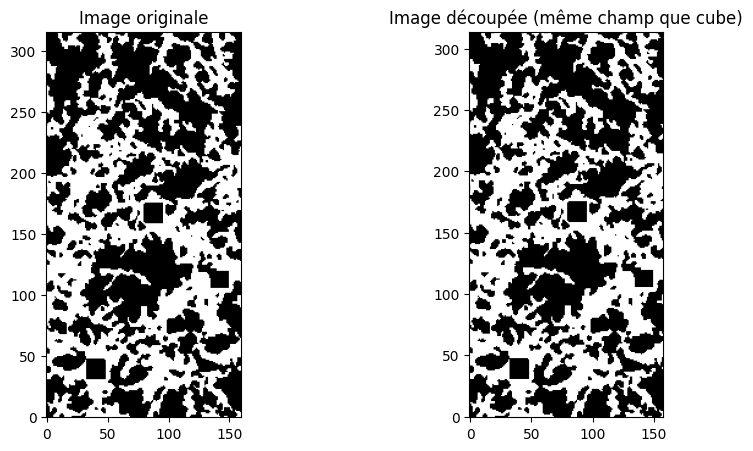

In [65]:

# WCS du spine et du cube
wcs_spine = WCS(data_spine_2[0].header).celestial
wcs_cube = WCS(data_reproject[0].header).celestial

# Dimensions
ny_cube, nx_cube = data_reproject[0].data.shape[-2:]

# Coordonnées pixel du cube dans son propre WCS
x_cube = np.array([0, nx_cube])
y_cube = np.array([0, ny_cube])

# Convertir ces coins en coordonnées monde (GLON, GLAT)
lon, lat = wcs_cube.all_pix2world(x_cube, y_cube, 1)

# Puis convertir ces coins dans le WCS du spine
x_spine, y_spine = wcs_spine.all_world2pix(lon, lat, 1)

# Déterminer les bornes
x_min = int(np.floor(min(x_spine)))
x_max = int(np.ceil(max(x_spine)))
y_min = int(np.floor(min(y_spine)))
y_max = int(np.ceil(max(y_spine)))

print(f"Découpe du spine : x=({x_min},{x_max}), y=({y_min},{y_max})")

# Appliquer la découpe
data_spine_cut = data_spine_2[0].data[y_min:y_max, x_min:x_max]
print("cut shape", data_spine_cut.shape)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(data_spine_2[0].data, origin='lower', cmap='gray')
plt.title("Image originale")
plt.subplot(1, 2, 2)
plt.imshow(data_spine_cut, origin='lower', cmap='gray')
plt.title("Image découpée (même champ que cube)")
plt.show()


In [1]:
x_min

NameError: name 'x_min' is not defined

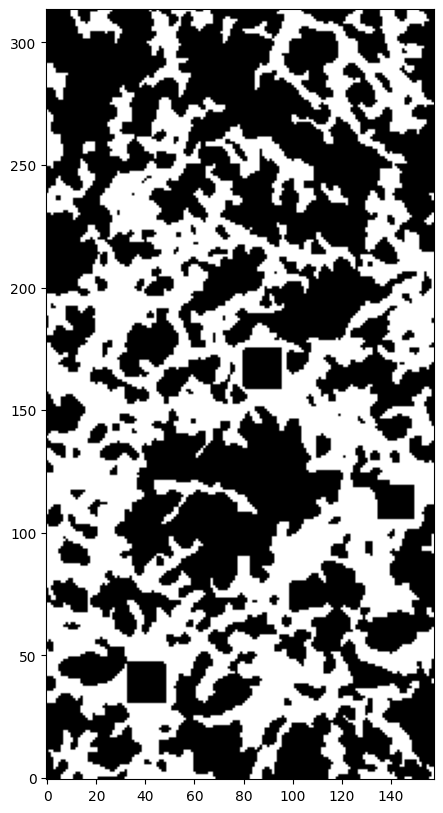

In [34]:
plt.figure(figsize=(10, 10))
plt.imshow(data_spine_cut, origin='lower', cmap='gray')

In [35]:
data_spine_cut.max()
data_spine_cut.mean()

np.float64(0.4510803837781182)